<a href="https://colab.research.google.com/github/ajaykmahto/MTP_SSL/blob/main/web2vec2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os
from scipy.io import wavfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
import torch
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from statistics import mode
from scipy.signal import butter, filtfilt
import scipy.signal as signal
import scipy.signal
import zipfile

In [ ]:
# Unzip the data if it hasn't been unzipped yet
if not os.path.exists('/content/training'):
    with zipfile.ZipFile('/content/training.zip', 'r') as zip_ref:
        zip_ref.extractall('/content/training')

In [ ]:
# Function to load audio files
def load_audio_files(file_list):
    audio_data, record_names = [], []
    for file_path in file_list:
        sr, y = wavfile.read(file_path)
        audio_data.append(y)
        record_names.append(os.path.splitext(os.path.basename(file_path))[0])
    return audio_data, record_names, sr

# Function to normalize audio using z-score
def z_score_normalize_audio_data(audio_data):
    normalized_audio = []
    for signal in audio_data:
        mean_val, std_val = np.mean(signal), np.std(signal)
        # Return normalized signal as a list element
        normalized_audio.append((signal - mean_val) / std_val if std_val != 0 else signal - mean_val)
    return normalized_audio

# Function to extract Wav2Vec2.0 features
def extract_features(audio_data, processor, model, device):
    features = []
    for signal in audio_data:
        # Process audio signal and move to device
        inputs = processor(signal, padding=True, return_tensors='pt', sampling_rate=16000).input_values.to(device)
        with torch.no_grad():
            outputs = model(inputs, output_hidden_states=True)
        # Use the mean of the hidden states as the feature representation
        features.append(outputs.hidden_states[1].mean(dim=1).cpu().numpy())
    return np.array(features)

In [ ]:
# Function to fragment audio data with an odd number of fragments
def split_into_all_fragments(audio_data, labels, record_names, sample_rate, duration, overlap):
    num_samples = int(duration * sample_rate)
    #overlaping condition
    step = num_samples - int((overlap * 0.01) * num_samples)
    fragmented_data, fragment_labels, fragment_record_names = [], [], []
    for i in range(len(audio_data)):
        signal = audio_data[i]
        label = labels[i]
        record_name = record_names[i]
        if len(signal)<num_samples:
            signal = np.pad(signal, (0, num_samples - len(signal)), mode='constant')
        num_fragments = (len(signal) - num_samples) // step + 1
        if num_fragments % 2 == 0:
            num_fragments -= 1 # Ensure an odd number of fragments
        for j in range(num_fragments):
            fragmented_data.append(signal[j * step:j * step + num_samples-1])
            fragment_labels.append(label)
            fragment_record_names.append(record_name)
    return np.array(fragmented_data), np.array(fragment_labels), fragment_record_names

In [ ]:
def majority_voting_sum_with_metrics(true_labels, pred_labels, record_names):
    majority_labels, true_labels_per_record, record_name = [], [], []
    unique_records = np.unique(record_names)
    for record in unique_records:
        # Extract predictions and true labels for the current record
        fragment_preds = np.array(pred_labels)[np.array(record_names) == record]
        fragment_trues = np.array(true_labels)[np.array(record_names) == record]
        # Majority voting using sum
        majority_label = mode(fragment_preds)
        # Store results
        majority_labels.append(majority_label)
        true_labels_per_record.append(fragment_trues[0]) # Assuming all fragments have the same true label
        record_name.append(record)
    return np.array(majority_labels), np.array(true_labels_per_record), record_name


In [ ]:
# Load data
folder_path = '/content/training'
subfolders = sorted([f.path for f in os.scandir(folder_path) if f.is_dir() and f.name.startswith('training-')])

# Load reference labels
df_combined = pd.concat([pd.read_csv(os.path.join(sub, 'REFERENCE.csv'), names=['Record name', 'Type (-1=normal 1=abnormal)']) for sub in subfolders], ignore_index=True)

# Load audio files
audio_files = [os.path.join(sub, file) for sub in subfolders for file in os.listdir(sub) if file.endswith('.wav')]
audio_files.sort()
audio_data, record_names_loaded, sample_rate = load_audio_files(audio_files)
record_names_loaded = np.array(record_names_loaded)

# Fragment length for audio
target_length = 5.0 # in seconds
overlapping= 10 #in %

# Apply Z-Score Normalization (Returns a list of arrays to handle varying lengths)
audio_data_norm = z_score_normalize_audio_data(audio_data)

# Load Wav2Vec2.0
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h").to(device)

# Convert labels for lookup
df_combined.set_index('Record name', inplace=True)
y=df_combined['Type (-1=normal 1=abnormal)'].values

# k-Fold Cross Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results
conf_matrices = []
sub_conf_matrices = []
accuracies, sensitivities, specificities, precisions, f1_scores = [], [], [], [], []
sub_accuracies, sub_sensitivities, sub_specificities, sub_precisions, sub_f1_scores = [], [], [], [], []

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Creating training fragments Fold 1 ----------

Creating testing fragments Fold 1 ----------

Extracting training features ----------

Extracting testing features ----------

Standardizing features ----------

Training in progress ----------

Training completed ----------

===============================Fold: 1==============================

Fragment label metric::::::::::::

Accuracy: 92.29%
Sensitivity (Recall): 84.72
Specificity: 95.09
Precision: 86.44
F1 Score: 85.57
UAR: 89.91


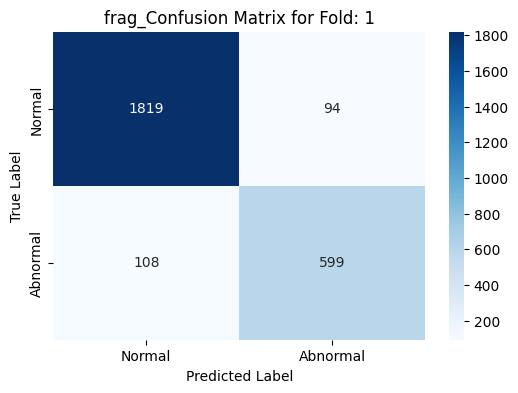

Subject level metric::::::::::::

Sub_Accuracy: 92.90%
Sub_Sensitivity (Recall): 77.44
Sub_Specificity: 96.89
Sub_Precision: 86.55
Sub_F1 Score: 81.75
Sub_UAR: 87.17


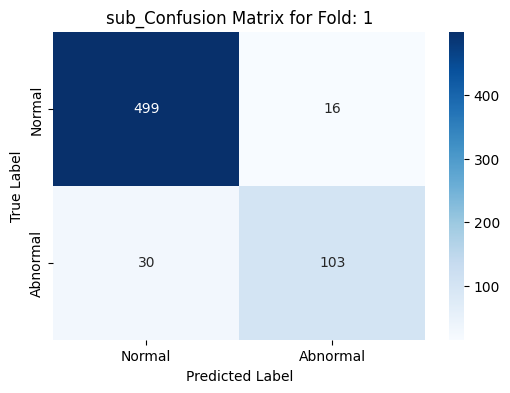

Creating training fragments Fold 2 ----------

Creating testing fragments Fold 2 ----------

Extracting training features ----------

Extracting testing features ----------

Standardizing features ----------

Training in progress ----------

Training completed ----------

===============================Fold: 2==============================

Fragment label metric::::::::::::

Accuracy: 92.49%
Sensitivity (Recall): 85.47
Specificity: 94.71
Precision: 83.61
F1 Score: 84.53
UAR: 90.09


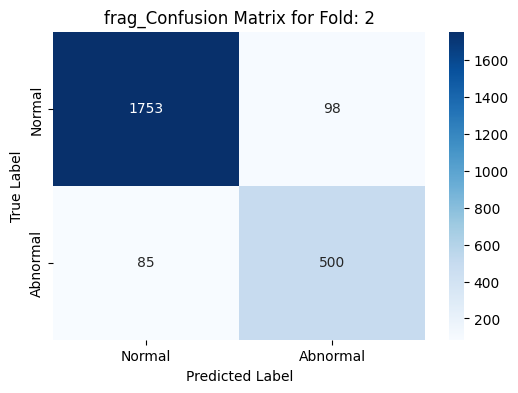

Subject level metric::::::::::::

Sub_Accuracy: 92.75%
Sub_Sensitivity (Recall): 79.70
Sub_Specificity: 96.12
Sub_Precision: 84.13
Sub_F1 Score: 81.85
Sub_UAR: 87.91


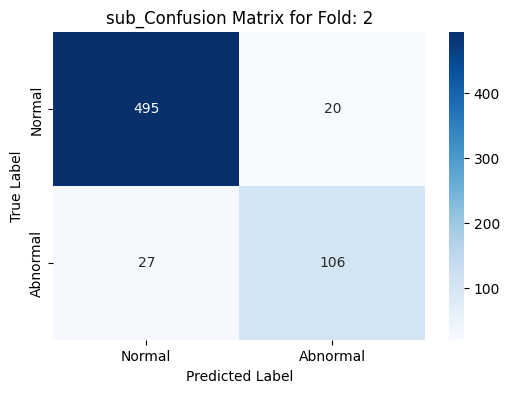

Creating training fragments Fold 3 ----------

Creating testing fragments Fold 3 ----------

Extracting training features ----------

Extracting testing features ----------

Standardizing features ----------

Training in progress ----------

Training completed ----------

===============================Fold: 3==============================

Fragment label metric::::::::::::

Accuracy: 92.48%
Sensitivity (Recall): 80.07
Specificity: 95.99
Precision: 84.98
F1 Score: 82.45
UAR: 88.03


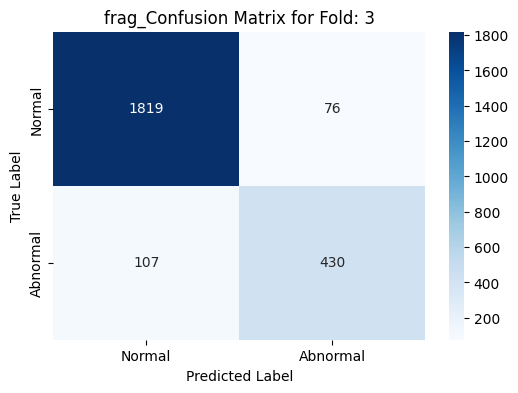

Subject level metric::::::::::::

Sub_Accuracy: 92.28%
Sub_Sensitivity (Recall): 75.19
Sub_Specificity: 96.70
Sub_Precision: 85.47
Sub_F1 Score: 80.00
Sub_UAR: 85.94


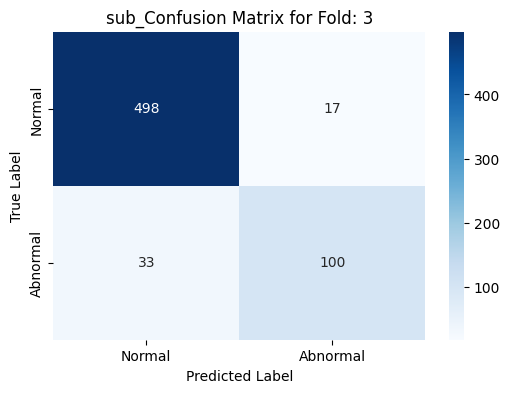

Creating training fragments Fold 4 ----------

Creating testing fragments Fold 4 ----------

Extracting training features ----------

Extracting testing features ----------

Standardizing features ----------

Training in progress ----------

Training completed ----------

===============================Fold: 4==============================

Fragment label metric::::::::::::

Accuracy: 93.38%
Sensitivity (Recall): 88.21
Specificity: 95.07
Precision: 85.45
F1 Score: 86.80
UAR: 91.64


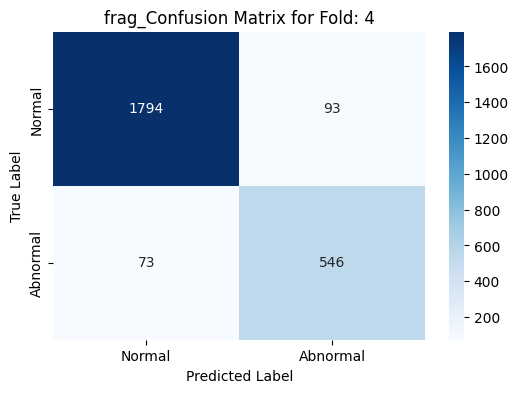

Subject level metric::::::::::::

Sub_Accuracy: 93.98%
Sub_Sensitivity (Recall): 82.71
Sub_Specificity: 96.89
Sub_Precision: 87.30
Sub_F1 Score: 84.94
Sub_UAR: 89.80


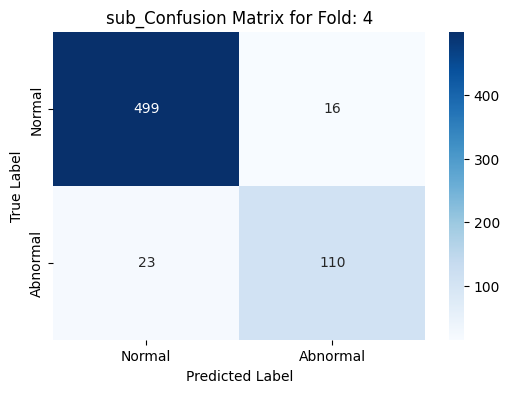

Creating training fragments Fold 5 ----------

Creating testing fragments Fold 5 ----------

Extracting training features ----------

Extracting testing features ----------

Standardizing features ----------

Training in progress ----------

Training completed ----------

===============================Fold: 5==============================

Fragment label metric::::::::::::

Accuracy: 94.49%
Sensitivity (Recall): 83.08
Specificity: 97.90
Precision: 92.19
F1 Score: 87.40
UAR: 90.49


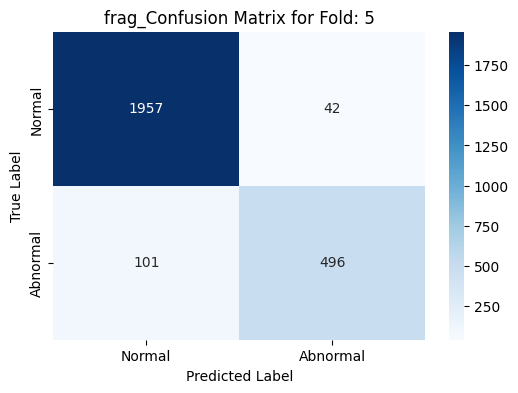

Subject level metric::::::::::::

Sub_Accuracy: 94.75%
Sub_Sensitivity (Recall): 79.70
Sub_Specificity: 98.64
Sub_Precision: 93.81
Sub_F1 Score: 86.18
Sub_UAR: 89.17


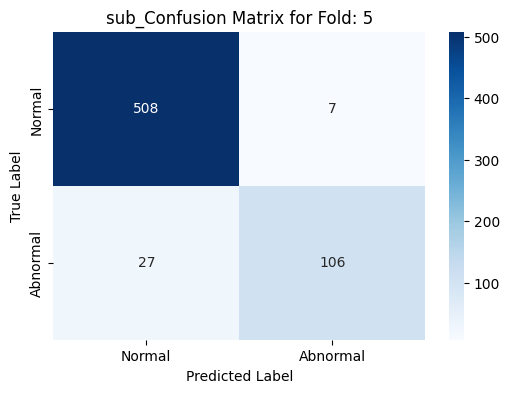

In [ ]:
fold = 0
for train_idx, test_idx in kf.split(audio_data_norm, y):
    fold += 1
    # Split the data into train and test using list comprehensions for the list object
    X_train_audio = [audio_data_norm[i] for i in train_idx]
    X_test_audio = [audio_data_norm[i] for i in test_idx]

    y_train_audio, y_test_audio = y[train_idx], y[test_idx]
    x_train_record, x_test_record = record_names_loaded[train_idx], record_names_loaded[test_idx]

    # Then, use the correct data for the training and testing fragments
    print(f'Creating training fragments Fold {fold} ----------\n')
    fragmented_train_audio, train_labels, train_record_names = split_into_all_fragments(X_train_audio, y_train_audio, x_train_record, sample_rate, duration=target_length, overlap=overlapping)
    print(f'Creating testing fragments Fold {fold} ----------\n')
    fragmented_test_audio, test_labels, test_record_names = split_into_all_fragments(X_test_audio, y_test_audio, x_test_record, sample_rate, duration=target_length, overlap=overlapping)

    # Extract features
    print('Extracting training features ----------\n')
    train_features = extract_features(fragmented_train_audio, processor, model, device).reshape(len(fragmented_train_audio), -1)
    print('Extracting testing features ----------\n')
    test_features = extract_features(fragmented_test_audio, processor, model, device).reshape(len(fragmented_test_audio), -1)

    # Standardize features
    print('Standardizing features ----------\n')
    scaler = StandardScaler()
    train_features = scaler.fit_transform(train_features)
    test_features = scaler.transform(test_features)

    print('Training in progress ----------\n')
    # Train SVM
    svm_classifier = SVC(kernel='rbf')
    svm_classifier.fit(train_features, train_labels)
    print('Training completed ----------\n')

    # Predictions
    y_pred = svm_classifier.predict(test_features)

    # Compute performance metrics
    conf_matrix = confusion_matrix(test_labels, y_pred)
    conf_matrices.append(conf_matrix)
    accuracy = accuracy_score(test_labels, y_pred)
    sensitivity = recall_score(test_labels, y_pred)
    tn, fp, fn, tp = conf_matrix.ravel()
    specificity = tn / (tn + fp)
    precision = precision_score(test_labels, y_pred)
    f1 = f1_score(test_labels, y_pred)
    accuracies.append(accuracy)
    sensitivities.append(sensitivity)
    specificities.append(specificity)
    precisions.append(precision)
    f1_scores.append(f1)
    uar = (sensitivity + specificity) / 2

    print(f"===============================Fold: {fold}==============================\n")
    print(f"Fragment label metric::::::::::::\n")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Sensitivity (Recall): {sensitivity* 100:.2f}")
    print(f"Specificity: {specificity* 100:.2f}")
    print(f"Precision: {precision* 100:.2f}")
    print(f"F1 Score: {f1* 100:.2f}")
    print(f"UAR: {uar* 100:.2f}")

    # Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='.0f', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f"frag_Confusion Matrix for Fold: {fold}")
    plt.show()

    # Majority Voting using Mode
    majority_labels, true_labels_per_record, record_name = majority_voting_sum_with_metrics(test_labels, y_pred, test_record_names)
    print(f"Subject level metric::::::::::::\n")
    sub_conf_matrix = confusion_matrix(true_labels_per_record, majority_labels)
    sub_conf_matrices.append(sub_conf_matrix)
    sub_accuracy = accuracy_score(true_labels_per_record, majority_labels)
    sub_sensitivity = recall_score(true_labels_per_record, majority_labels)
    tn_s, fp_s, fn_s, tp_s = sub_conf_matrix.ravel()
    sub_specificity = tn_s / (tn_s + fp_s)
    sub_precision = precision_score(true_labels_per_record, majority_labels)
    sub_f1 = f1_score(true_labels_per_record, majority_labels)
    sub_accuracies.append(sub_accuracy)
    sub_sensitivities.append(sub_sensitivity)
    sub_specificities.append(sub_specificity)
    sub_precisions.append(sub_precision)
    sub_f1_scores.append(sub_f1)
    sub_uar = (sub_sensitivity + sub_specificity) / 2
    print(f"Sub_Accuracy: {sub_accuracy * 100:.2f}%")
    print(f"Sub_Sensitivity (Recall): {sub_sensitivity* 100:.2f}")
    print(f"Sub_Specificity: {sub_specificity* 100:.2f}")
    print(f"Sub_Precision: {sub_precision* 100:.2f}")
    print(f"Sub_F1 Score: {sub_f1* 100:.2f}")
    print(f"Sub_UAR: {sub_uar* 100:.2f}")

    # Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(sub_conf_matrix, annot=True, fmt='.0f', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f"sub_Confusion Matrix for Fold: {fold}")
    plt.show()

Mean Accuracy: 93.02%
Mean Sensitivity (Recall): 84.31
Mean Specificity: 95.75
Mean Precision: 86.53
Mean F1 Score: 85.35
Mean UAR: 90.03


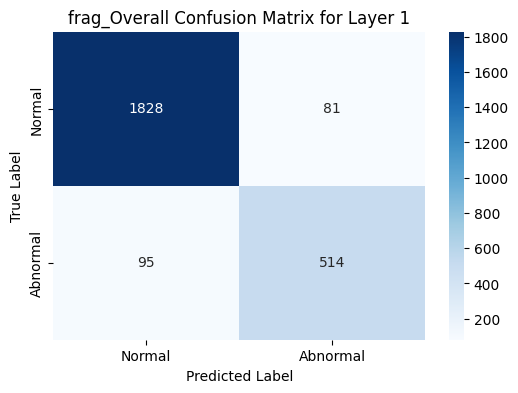

sub_Mean Accuracy: 93.33%
sub_Mean Sensitivity (Recall): 78.95
sub_Mean Specificity: 97.05
sub_Mean Precision: 87.45
sub_Mean F1 Score: 82.94
sub_Mean UAR: 88.00


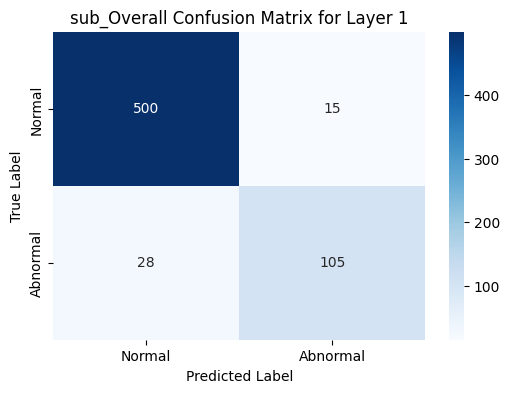

In [ ]:
#fragmentwise Final Metrics
mean_accuracy = np.mean(accuracies)
mean_sensitivity = np.mean(sensitivities)
mean_specificity = np.mean(specificities)
mean_precision = np.mean(precisions)
mean_f1_score = np.mean(f1_scores)
uar = (mean_sensitivity + mean_specificity) / 2
overall_conf_matrix = np.mean(conf_matrices, axis=0)
print(f"Mean Accuracy: {mean_accuracy * 100:.2f}%")
print(f"Mean Sensitivity (Recall): {mean_sensitivity* 100:.2f}")
print(f"Mean Specificity: {mean_specificity* 100:.2f}")
print(f"Mean Precision: {mean_precision* 100:.2f}")
print(f"Mean F1 Score: {mean_f1_score* 100:.2f}")
print(f"Mean UAR: {uar* 100:.2f}")

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(overall_conf_matrix, annot=True, fmt='.0f', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('frag_Overall Confusion Matrix for Layer 1')
plt.show()

# subjectwise Final Metrics
sub_mean_accuracy = np.mean(sub_accuracies)
sub_mean_sensitivity = np.mean(sub_sensitivities)
sub_mean_specificity = np.mean(sub_specificities)
sub_mean_precision = np.mean(sub_precisions)
sub_mean_f1_score = np.mean(sub_f1_scores)
sub_uar = (sub_mean_sensitivity + sub_mean_specificity) / 2
sub_overall_conf_matrix = np.mean(sub_conf_matrices, axis=0)
print(f"sub_Mean Accuracy: {sub_mean_accuracy * 100:.2f}%")
print(f"sub_Mean Sensitivity (Recall): {sub_mean_sensitivity* 100:.2f}")
print(f"sub_Mean Specificity: {sub_mean_specificity* 100:.2f}")
print(f"sub_Mean Precision: {sub_mean_precision* 100:.2f}")
print(f"sub_Mean F1 Score: {sub_mean_f1_score* 100:.2f}")
print(f"sub_Mean UAR: {sub_uar* 100:.2f}")

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(sub_overall_conf_matrix, annot=True, fmt='.0f', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('sub_Overall Confusion Matrix for Layer 1')
plt.show()